# Time Series Forecasting Project - Part 2: Rose.csv

The primary objective of this project is to analyze and forecast wine sales trends for the 20th century based on historical data provided by ABC Estate Wines. We aim to equip ABC Estate Wines with the necessary insights and foresight to enhance sales performance, capitalize on emerging market opportunities, and maintain a competitive edge in the wine industry.

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Command to tell Python to actually display the graphs
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.linear_model import LinearRegression
from sklearn import metrics
import statsmodels.api as sm
from sklearn.metrics import  mean_squared_error
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt


# set working directory
import os
os.getcwd()
os.chdir('C:\\Users\\POONAM TEKWANI\\Downloads')


# this two lines of code is just to increase the size of the display
from IPython.core.display import display, HTML 
display(HTML('<style>.container { width:90% !important; }<\style>'))


# Define the problem and perform Exploratory Data Analysis
- Read the data as an appropriate time series data - Plot the data - Perform EDA - Perform Decomposition

In [2]:
# read data
df = pd.read_csv("Rose.csv",parse_dates=True,squeeze=True,index_col=0)
df = pd.DataFrame(df)

In [3]:
# top rows
df.head()

,Rose
YearMonth,
1980-01-01,112.0
1980-02-01,118.0
1980-03-01,129.0
1980-04-01,99.0
1980-05-01,116.0


In [4]:
# last  rows
df.tail()

,Rose
YearMonth,
1995-03-01,45.0
1995-04-01,52.0
1995-05-01,28.0
1995-06-01,40.0
1995-07-01,62.0


In [5]:
# number of rows and columns
df.shape

(187, 1)

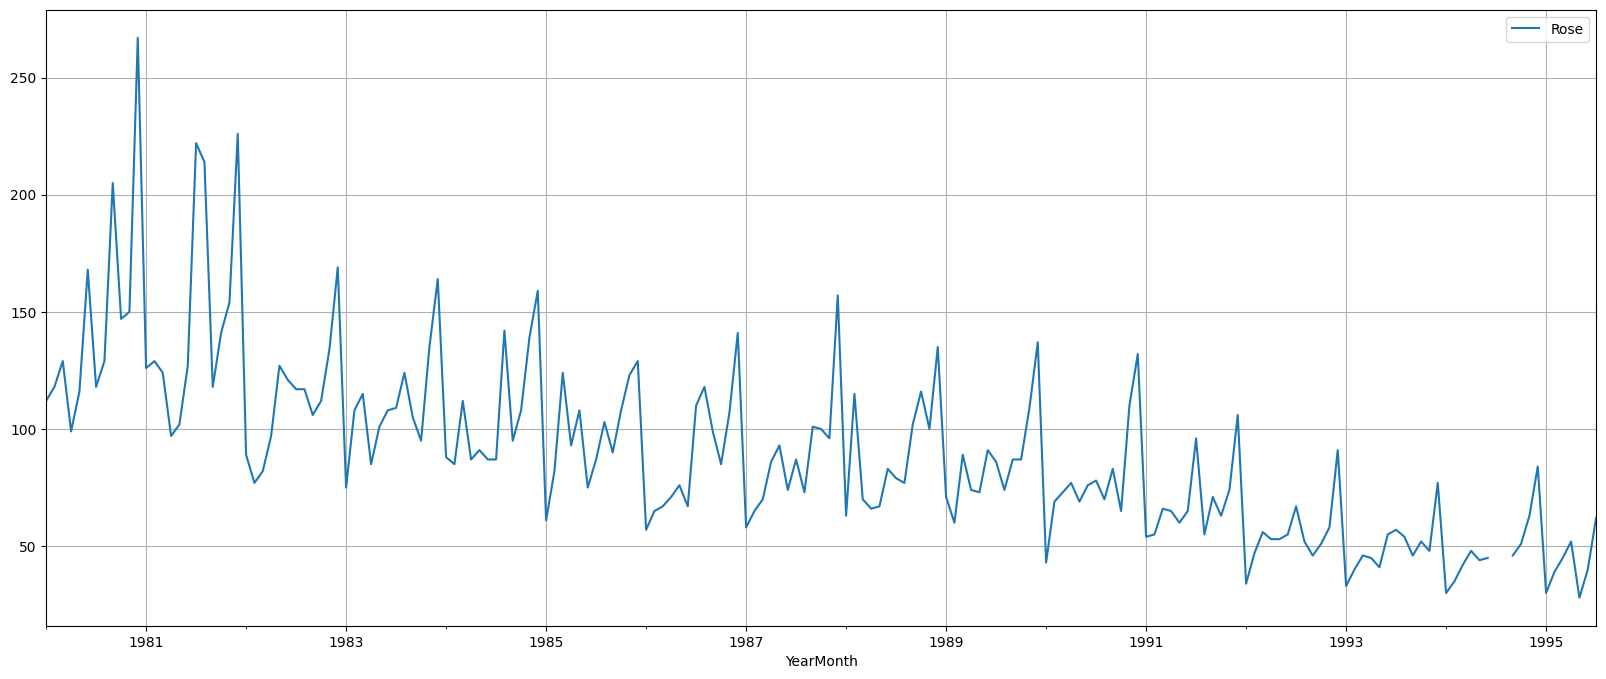

In [6]:
# plot 
df.plot(figsize=(20,8))
plt.grid();

In [7]:
df['Year']=df.index.year
df['Month']=df.index.month
df.head()

,Rose,Year,Month
YearMonth,,,
1980-01-01,112.0,1980,1
1980-02-01,118.0,1980,2
1980-03-01,129.0,1980,3
1980-04-01,99.0,1980,4
1980-05-01,116.0,1980,5


In [8]:
df.columns=['Sales', 'Year', 'Month']
df.head()

,Sales,Year,Month
YearMonth,,,
1980-01-01,112.0,1980,1
1980-02-01,118.0,1980,2
1980-03-01,129.0,1980,3
1980-04-01,99.0,1980,4
1980-05-01,116.0,1980,5


In [9]:
# number of rows and columns
df.shape

(187, 3)

In [10]:
# datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 187 entries, 1980-01-01 to 1995-07-01
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   185 non-null    float64
 1   Year    187 non-null    int64  
 2   Month   187 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 5.8 KB


In [11]:
# statistical summary
round(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Sales,185.0,90.0,39.0,28.0,63.0,86.0,112.0,267.0
Year,187.0,1987.0,5.0,1980.0,1983.0,1987.0,1991.0,1995.0
Month,187.0,6.0,3.0,1.0,3.0,6.0,9.0,12.0


In [12]:
# isnull
df.isnull().sum()

Sales    2
Year     0
Month    0
dtype: int64

In [13]:
df[df['Sales'].isna()]

,Sales,Year,Month
YearMonth,,,
1994-07-01,NaN,1994,7
1994-08-01,NaN,1994,8


In [14]:
df['Sales_Before_After_Mean']=df['Sales']

In [15]:
np.mean(df[df.Month==7]['1993-07-01':'1995-07-01']['Sales'])

59.5

In [16]:
df.loc['1994-07-01', 'Sales_Before_After_Mean']=np.mean(
    df[df.Month==7]['1993-07-01':'1995-07-01']['Sales'])
df.loc['1994-08-01', 'Sales_Before_After_Mean']=np.mean(
    df[df.Month==8]['1993-08-01':'1995-08-01']['Sales'])

df[df['Sales_Before_After_Mean'].isna()]

,Sales,Year,Month,Sales_Before_After_Mean
YearMonth,,,,


In [17]:
df.loc['1994-07-01':'1994-08-01']

,Sales,Year,Month,Sales_Before_After_Mean
YearMonth,,,,
1994-07-01,NaN,1994,7,59.5
1994-08-01,NaN,1994,8,54.0


In [18]:
df[df.Month==7]

,Sales,Year,Month,Sales_Before_After_Mean
YearMonth,,,,
1980-07-01,118.0,1980,7,118.0
1981-07-01,222.0,1981,7,222.0
1982-07-01,117.0,1982,7,117.0
1983-07-01,109.0,1983,7,109.0
1984-07-01,87.0,1984,7,87.0
1985-07-01,87.0,1985,7,87.0
1986-07-01,110.0,1986,7,110.0
1987-07-01,87.0,1987,7,87.0
1988-07-01,79.0,1988,7,79.0


In [19]:
df[df.Month==8]

,Sales,Year,Month,Sales_Before_After_Mean
YearMonth,,,,
1980-08-01,129.0,1980,8,129.0
1981-08-01,214.0,1981,8,214.0
1982-08-01,117.0,1982,8,117.0
1983-08-01,124.0,1983,8,124.0
1984-08-01,142.0,1984,8,142.0
1985-08-01,103.0,1985,8,103.0
1986-08-01,118.0,1986,8,118.0
1987-08-01,73.0,1987,8,73.0
1988-08-01,77.0,1988,8,77.0


In [20]:
df.drop(['Sales'],inplace=True,axis=1)

df.head()

,Year,Month,Sales_Before_After_Mean
YearMonth,,,
1980-01-01,1980,1,112.0
1980-02-01,1980,2,118.0
1980-03-01,1980,3,129.0
1980-04-01,1980,4,99.0
1980-05-01,1980,5,116.0


In [21]:
# fill missing values in sales with the mean
df.columns=['Year', 'Month', 'Sales']
df.isnull().sum()

Year     0
Month    0
Sales    0
dtype: int64

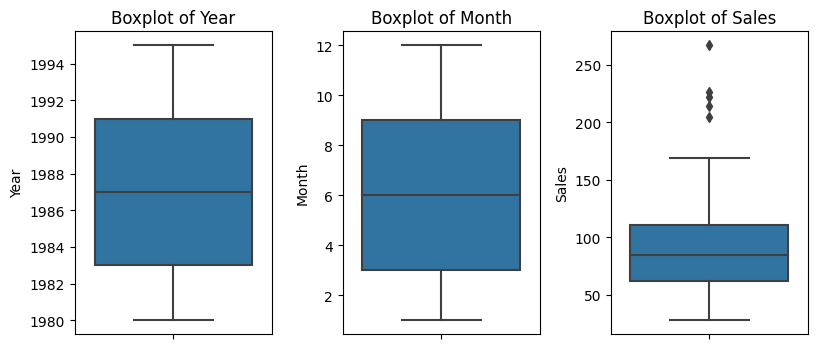

In [22]:
# boxplot

dfbox=df
plt.figure(figsize = (19,10))
feature_list = dfbox.columns
for i in range(len(feature_list)):
    plt.subplot(3, 7, i + 1)
    sns.boxplot(y = dfbox[feature_list[i]], data = dfbox)
    plt.title('Boxplot of {}'.format(feature_list[i]))
    plt.tight_layout()

<Axes: xlabel='YearMonth'>

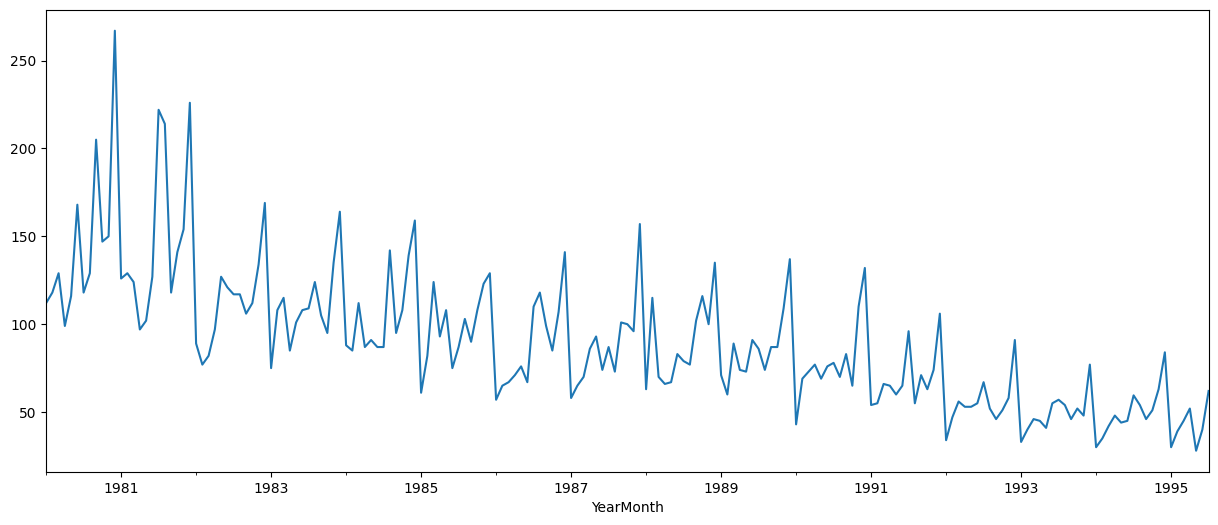

In [23]:
# Sales
plt.figure(figsize=(15,6))
df['Sales'].plot()

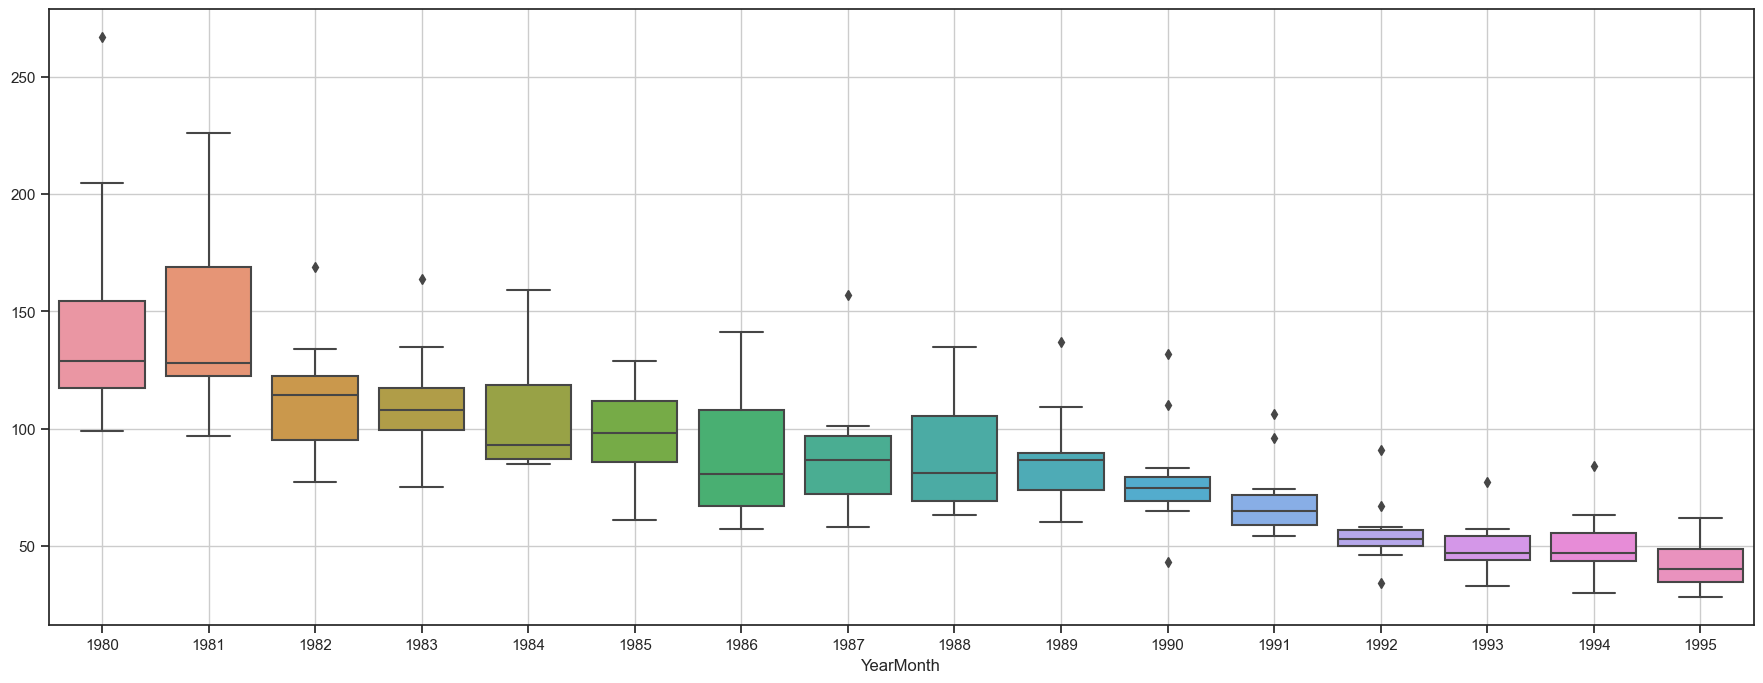

In [63]:
# Yearly_boxplot
_, ax = plt.subplots(figsize=(22,8))
sns.boxplot(x = df.index.year,y = df.values[:,2],ax=ax)
plt.grid();

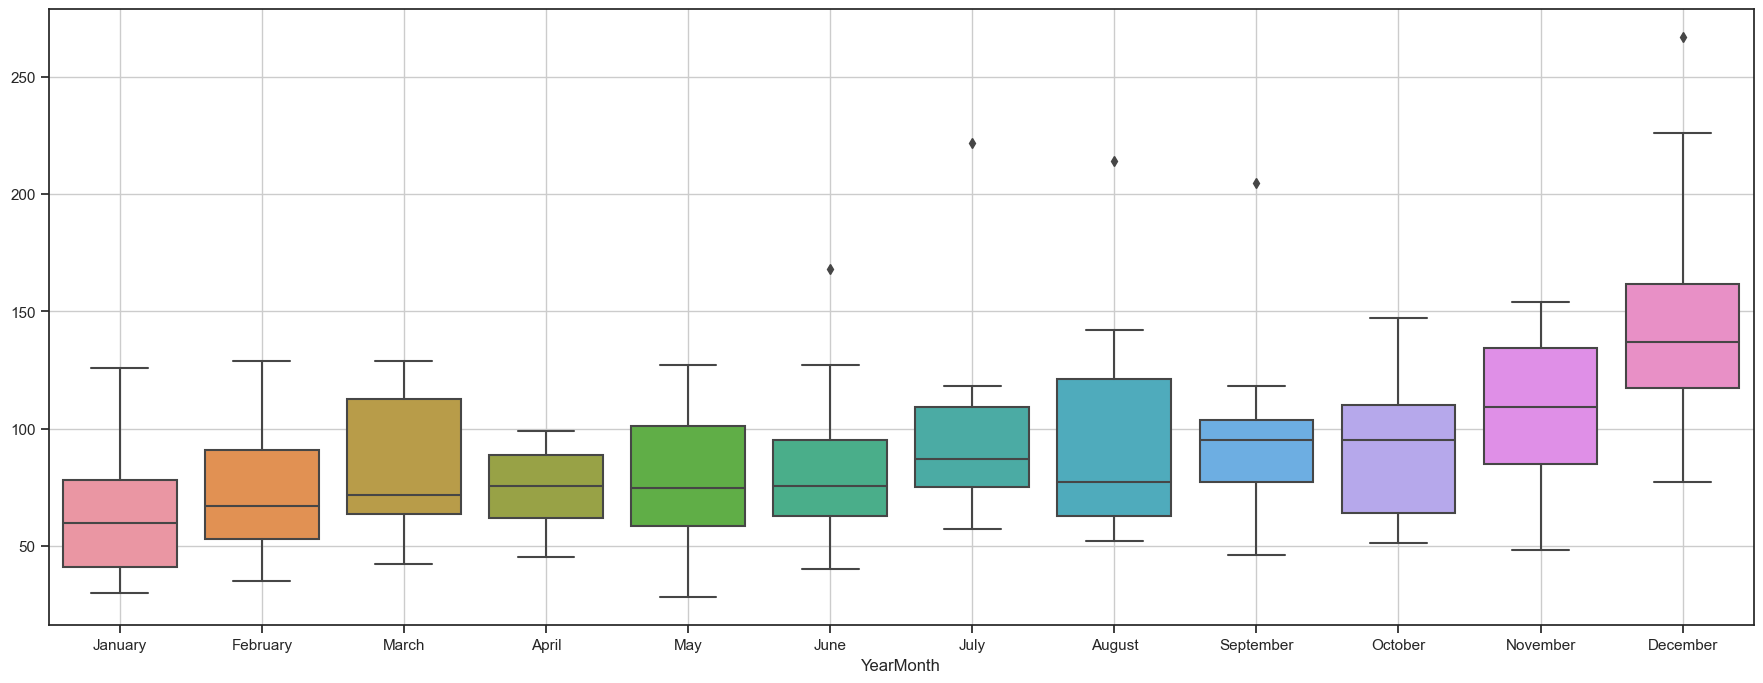

In [60]:
# Monthly_boxplot
_, ax = plt.subplots(figsize=(22,8))
sns.boxplot(x = df.index.month_name(),y = df.values[:,2],ax=ax)
plt.grid();

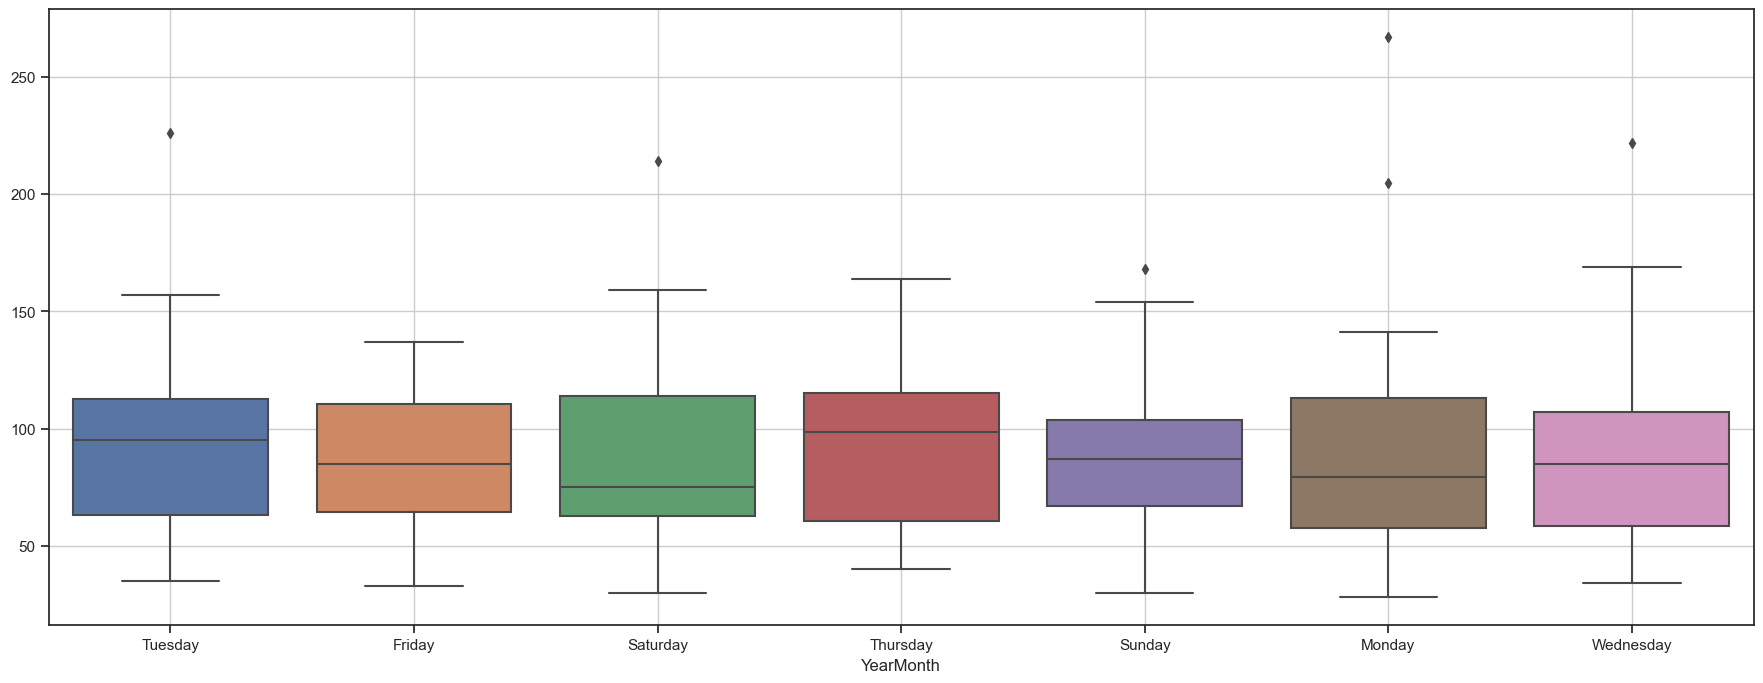

In [62]:
# Week days boxplot
_, ax = plt.subplots(figsize=(22,8))
sns.boxplot(x = df.index.day_name(),y = df.values[:,2],ax=ax)
plt.grid();

# Graph of monthly sales accross years

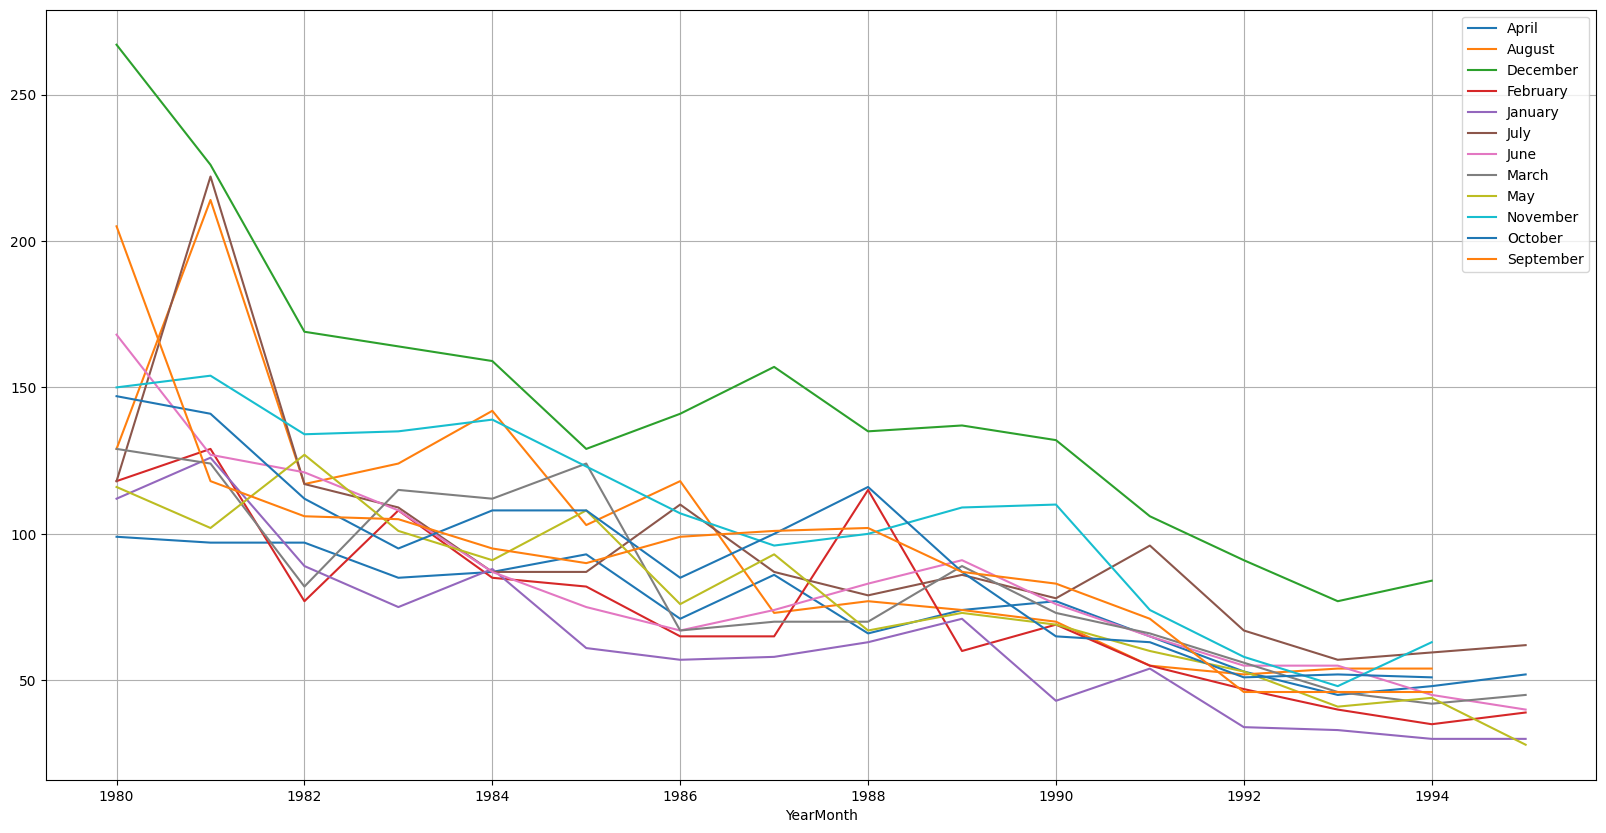

In [27]:
monthly_sales_across_years = pd.pivot_table(df, values = 'Sales', columns = df.index.month_name(), index = df.index.year)
monthly_sales_across_years.plot(figsize=(20,10))
plt.grid()
plt.legend(loc='best');

# Correlation plot

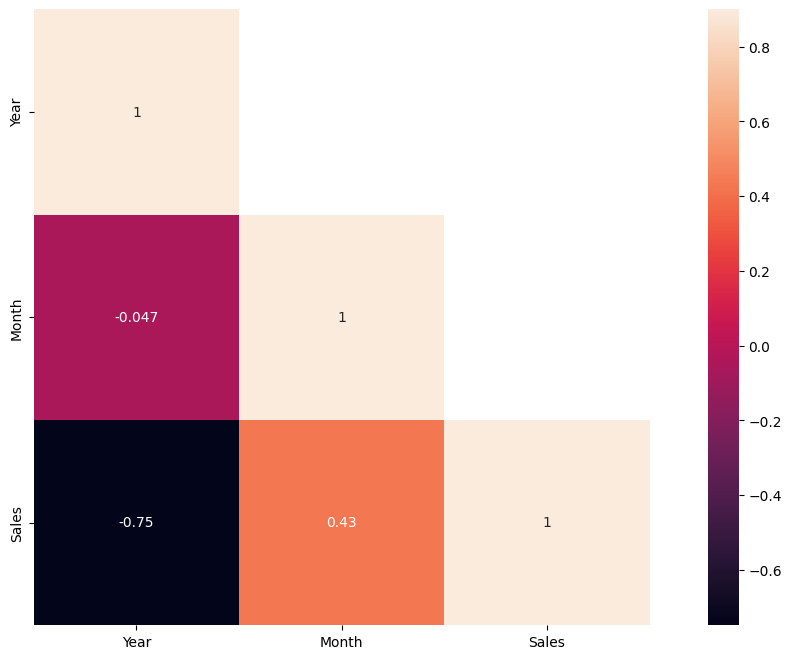

In [28]:
corr_all = df.corr()
mask = np.array(corr_all)
mask[np.tril_indices_from(mask)] = False
fig,ax= plt.subplots()
fig.set_size_inches(15,8)
sns.heatmap(corr_all, mask=mask,vmax=.9, square=True,annot=True);
plt.show()

# Plot ECDF: Empirical Cumulative Distribution Function

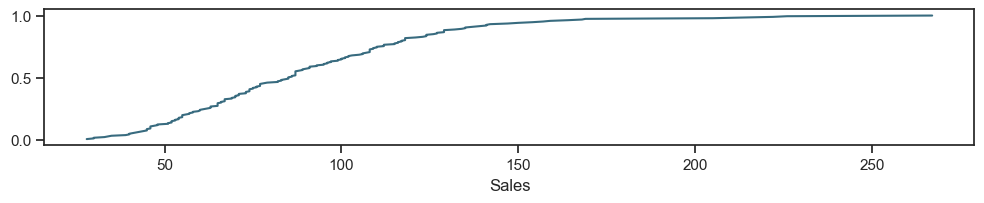

In [29]:
from statsmodels.distributions.empirical_distribution import ECDF

# time series analysis
sns.set(style = "ticks")# to format into seaborn 
c = '#386B7F' # basic color for plots
plt.figure(figsize = (12, 6))

  
plt.subplot(312)
cdf = ECDF(df['Sales'])
plt.plot(cdf.x, cdf.y, label = "statmodels", color = c)
plt.xlabel('Sales');

# Decomposition

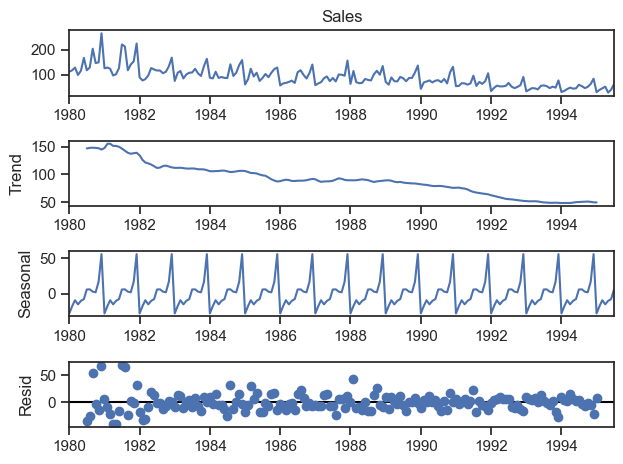

In [30]:
decomposition = seasonal_decompose(df['Sales'],model='additive')
decomposition.plot();

In [31]:
trend = decomposition.trend
seasonality = decomposition.seasonal
residual = decomposition.resid

print('Trend','\n',trend.head(12),'\n')
print('Seasonality','\n',seasonality.head(12),'\n')
print('Residual','\n',residual.head(12),'\n')

Trend 
 YearMonth
1980-01-01           NaN
1980-02-01           NaN
1980-03-01           NaN
1980-04-01           NaN
1980-05-01           NaN
1980-06-01           NaN
1980-07-01    147.083333
1980-08-01    148.125000
1980-09-01    148.375000
1980-10-01    148.083333
1980-11-01    147.416667
1980-12-01    145.125000
Name: trend, dtype: float64 

Seasonality 
 YearMonth
1980-01-01   -28.031994
1980-02-01   -17.543105
1980-03-01    -9.418105
1980-04-01   -15.230605
1980-05-01   -10.328819
1980-06-01    -7.810962
1980-07-01     5.718006
1980-08-01     5.931895
1980-09-01     2.651339
1980-10-01     1.748562
1980-11-01    16.723562
1980-12-01    55.590228
Name: seasonal, dtype: float64 

Residual 
 YearMonth
1980-01-01          NaN
1980-02-01          NaN
1980-03-01          NaN
1980-04-01          NaN
1980-05-01          NaN
1980-06-01          NaN
1980-07-01   -34.801339
1980-08-01   -25.056895
1980-09-01    53.973661
1980-10-01    -2.831895
1980-11-01   -14.140228
1980-12-01    66.28477

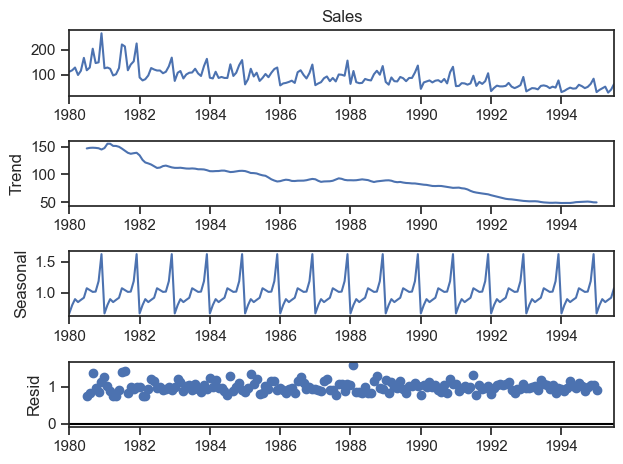

In [32]:
decomposition = seasonal_decompose(df['Sales'],model='multiplicative')
decomposition.plot();

In [33]:
trend = decomposition.trend
seasonality = decomposition.seasonal
residual = decomposition.resid

print('Trend','\n',trend.head(12),'\n')
print('Seasonality','\n',seasonality.head(12),'\n')
print('Residual','\n',residual.head(12),'\n')

Trend 
 YearMonth
1980-01-01           NaN
1980-02-01           NaN
1980-03-01           NaN
1980-04-01           NaN
1980-05-01           NaN
1980-06-01           NaN
1980-07-01    147.083333
1980-08-01    148.125000
1980-09-01    148.375000
1980-10-01    148.083333
1980-11-01    147.416667
1980-12-01    145.125000
Name: trend, dtype: float64 

Seasonality 
 YearMonth
1980-01-01    0.668577
1980-02-01    0.804550
1980-03-01    0.898744
1980-04-01    0.851237
1980-05-01    0.886934
1980-06-01    0.921546
1980-07-01    1.074644
1980-08-01    1.044683
1980-09-01    1.015406
1980-10-01    1.020108
1980-11-01    1.189232
1980-12-01    1.624338
Name: seasonal, dtype: float64 

Residual 
 YearMonth
1980-01-01         NaN
1980-02-01         NaN
1980-03-01         NaN
1980-04-01         NaN
1980-05-01         NaN
1980-06-01         NaN
1980-07-01    0.746542
1980-08-01    0.833636
1980-09-01    1.360672
1980-10-01    0.973117
1980-11-01    0.855614
1980-12-01    1.132642
Name: resid, dtype: fl

# Data Pre-processing
- Missing value treatment - Visualize the processed data - Train-test split

In [34]:
# Split the data into training and testing sets
train = df[df.index < '1991-01-01']
test = df[df.index >= '1991-01-01']

In [35]:
print('Shape of datasets:')
print("train dataset: ",train.shape)
print("test dataset: ",test.shape,'\n')
print('Rows of dataset: ')
print('First few rows of Training Data','\n',train.head(),'\n')
print('Last few rows of Training Data','\n',train.tail(),'\n')
print('First few rows of Test Data','\n',test.head(),'\n')
print('Last few rows of Test Data','\n',test.tail(),'\n')

Shape of datasets:
train dataset:  (132, 3)
test dataset:  (55, 3) 

Rows of dataset: 
First few rows of Training Data 
             Year  Month  Sales
YearMonth                     
1980-01-01  1980      1  112.0
1980-02-01  1980      2  118.0
1980-03-01  1980      3  129.0
1980-04-01  1980      4   99.0
1980-05-01  1980      5  116.0 

Last few rows of Training Data 
             Year  Month  Sales
YearMonth                     
1990-08-01  1990      8   70.0
1990-09-01  1990      9   83.0
1990-10-01  1990     10   65.0
1990-11-01  1990     11  110.0
1990-12-01  1990     12  132.0 

First few rows of Test Data 
             Year  Month  Sales
YearMonth                     
1991-01-01  1991      1   54.0
1991-02-01  1991      2   55.0
1991-03-01  1991      3   66.0
1991-04-01  1991      4   65.0
1991-05-01  1991      5   60.0 

Last few rows of Test Data 
             Year  Month  Sales
YearMonth                     
1995-03-01  1995      3   45.0
1995-04-01  1995      4   52.0
1995-0

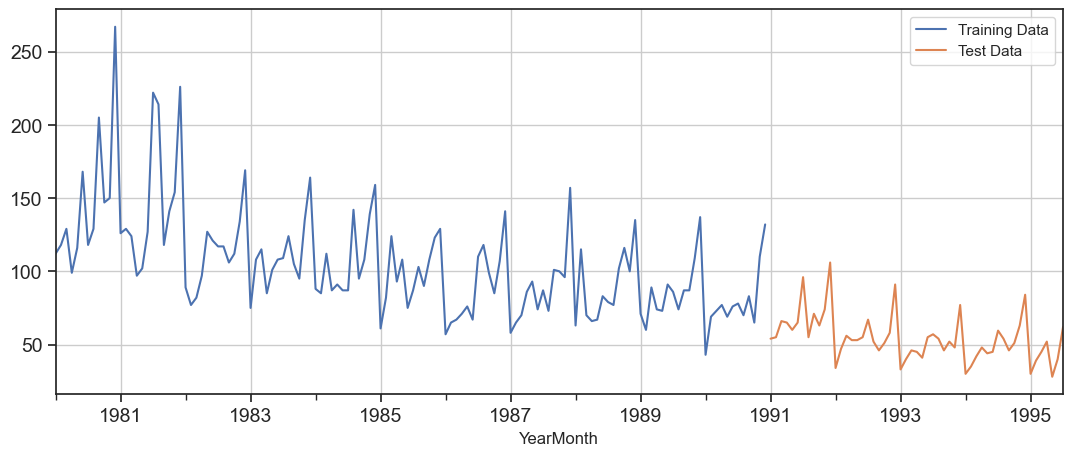

In [36]:
# Plot
train['Sales'].plot(figsize=(13,5), fontsize=14)
test['Sales'].plot(figsize=(13,5), fontsize=14)
plt.grid()
plt.legend(['Training Data','Test Data'])
plt.show()

# Model Building - Original Data
- Build forecasting models - Linear regression - Simple Average - Moving Average - Exponential Models (Single, Double, Triple) - Check the performance of the models built

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Extracting features (time) and target variable (sales)
x = df.index.map(lambda x: x.toordinal()).values.reshape(-1, 1)  # Time
y = df['Sales']  # Sales data

# Initialize and fit the linear regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(x, y)

# Make predictions
y_pred_linear = linear_reg_model.predict(x)

# Calculate Mean Squared Error (MSE)
mse_linear = mean_squared_error(y, y_pred_linear)
print("Linear Regression MSE:", mse_linear)


Linear Regression MSE: 730.9372527556712


In [38]:
# Simple Average Model
simple_avg_forecast = df['Sales'].mean()
print("Simple Average Forecast:", simple_avg_forecast)

Simple Average Forecast: 90.03475935828877


In [39]:
# Moving Average Model
window_size = 3  # Specify the number of past observations to consider
moving_avg_forecast = df['Sales'].rolling(window=window_size).mean().iloc[-1]
print("Moving Average Forecast (Window Size {}):".format(window_size), moving_avg_forecast)

Moving Average Forecast (Window Size 3): 43.333333333333336


In [40]:
# Exponential Models
# Single Exponential Smoothing Model
single_exp_model = ExponentialSmoothing(df['Sales']).fit()
single_exp_forecast = single_exp_model.forecast(1).iloc[0]
print("Single Exponential Smoothing Forecast:", single_exp_forecast)

Single Exponential Smoothing Forecast: 48.52161447611094


C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [41]:
# Double Exponential Smoothing Model
double_exp_model = ExponentialSmoothing(df['Sales'], trend='add').fit()
double_exp_forecast = double_exp_model.forecast(1).iloc[0]
print("Double Exponential Smoothing Forecast:", double_exp_forecast)


Double Exponential Smoothing Forecast: 41.06502119128974


C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [42]:
# Triple Exponential Smoothing Model
triple_exp_model = ExponentialSmoothing(df['Sales'], trend='add', seasonal='add', seasonal_periods=12).fit()
triple_exp_forecast = triple_exp_model.forecast(1).iloc[0]
print("Triple Exponential Smoothing Forecast:", triple_exp_forecast)

C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Triple Exponential Smoothing Forecast: 51.78946851503534


In [43]:
from sklearn.metrics import mean_squared_error

# Calculate Mean Squared Error (MSE) for Linear Regression
mse_linear = mean_squared_error(df['Sales'], y_pred_linear)
print("Linear Regression MSE:", mse_linear)

# Calculate Mean Squared Error (MSE) for Simple Average
mse_simple_avg = mean_squared_error(df['Sales'], [simple_avg_forecast] * len(df))
print("Simple Average MSE:", mse_simple_avg)

# Calculate Mean Squared Error (MSE) for Moving Average
mse_moving_avg = mean_squared_error(df['Sales'], [moving_avg_forecast] * len(df))
print("Moving Average MSE:", mse_moving_avg)

# Calculate Mean Squared Error (MSE) for Single Exponential Smoothing
mse_single_exp = mean_squared_error(df['Sales'], [single_exp_forecast] * len(df))
print("Single Exponential Smoothing MSE:", mse_single_exp)

# Calculate Mean Squared Error (MSE) for Double Exponential Smoothing
mse_double_exp = mean_squared_error(df['Sales'], [double_exp_forecast] * len(df))
print("Double Exponential Smoothing MSE:", mse_double_exp)

# Calculate Mean Squared Error (MSE) for Triple Exponential Smoothing
mse_triple_exp = mean_squared_error(df['Sales'], [triple_exp_forecast] * len(df))
print("Triple Exponential Smoothing MSE:", mse_triple_exp)


Linear Regression MSE: 730.9372527556712
Simple Average MSE: 1522.144513712145
Moving Average MSE: 3703.1677064765295
Single Exponential Smoothing MSE: 3245.4857117208326
Double Exponential Smoothing MSE: 3920.1797698565874
Triple Exponential Smoothing MSE: 2984.8467853971897


Linear Regression has the lowest MSE (730.94), indicating it provides the most accurate predictions among the methods compared.

Simple Average has a higher MSE (1522.14), indicating that it performs worse than linear regression.

Moving Average has an even higher MSE (3703.17), indicating that it performs worse than both linear regression and simple average.

Single Exponential Smoothing, Double Exponential Smoothing, and Triple Exponential Smoothing have MSE values of 3245.49, 3920.18, and 2984.85 respectively, indicating their performance falls between Simple Average and Moving Average but worse than Linear Regression.

These results suggest that, based on the MSE metric, Linear Regression is the best-performing method among the ones evaluated for forecasting the given time series data.

# Check for Stationarity
- Check for stationarity - Make the data stationary (if needed)

To check for stationarity and make the data stationary if needed, you can follow these steps:

Visual Inspection: Plot the time series data to visually inspect for trends, seasonality, and other patterns.

Statistical Tests: Use statistical tests like the Augmented Dickey-Fuller (ADF) test to formally check for stationarity. A low p-value (< 0.05) suggests stationarity.

Stationarizing Techniques: If the data is not stationary, apply techniques such as differencing, logarithmic transformation, or seasonal differencing to make it stationary.

Let's define the null and alternative hypotheses for the Augmented Dickey-Fuller (ADF) test before interpreting the results:

Null Hypothesis (H0): The time series data has a unit root and is non-stationary.
Alternative Hypothesis (H1): The time series data does not have a unit root and is stationary.

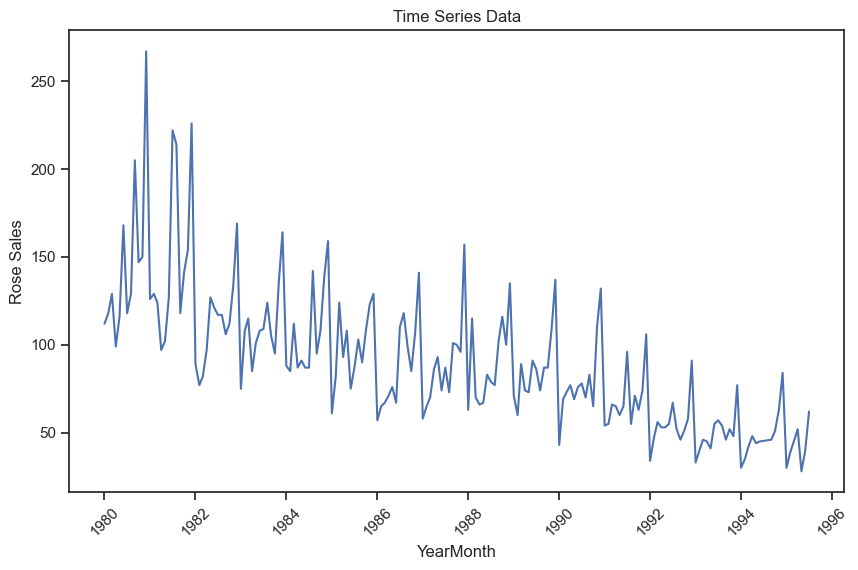

ADF Statistic: -1.8380327966021883
p-value: 0.3617495457657596
Critical Values:
	1%: -3.4691814633722453
	5%: -2.878595143532943
	10%: -2.5758625549741803


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Load the time series data
# Replace 'your_data.csv' with the path to your data file
data = pd.read_csv('Rose.csv')

# Assuming the index represents dates, set it as the index
data['YearMonth'] = pd.to_datetime(data['YearMonth'])  # Convert to datetime
data.set_index('YearMonth', inplace=True)

# Drop rows with missing or infinite values
data.dropna(inplace=True)  # Drop rows with missing values
data = data[~data.isin([np.nan, np.inf, -np.inf]).any(1)]  # Drop rows with infinite values

# Visual inspection
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['Rose'])
plt.title('Time Series Data')
plt.xlabel('YearMonth')
plt.ylabel('Rose Sales')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

# Perform Augmented Dickey-Fuller test for stationarity
result = adfuller(data['Rose'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value}')


The results of the Augmented Dickey-Fuller (ADF) test are as follows:

ADF Statistic: -1.8380327966021883
p-value: 0.3617495457657596
The ADF statistic is less than the critical values at all common significance levels (1%, 5%, and 10%), and the p-value is greater than 0.05.

Interpretation:
Since the ADF statistic is more negative than the critical values and the p-value is greater than the significance level (e.g., 0.05), we fail to reject the null hypothesis. Therefore, we do not have enough evidence to conclude that the time series is stationary.

In other words, the time series data for rose sales appears to be non-stationary based on the ADF test results.

# stationary technique

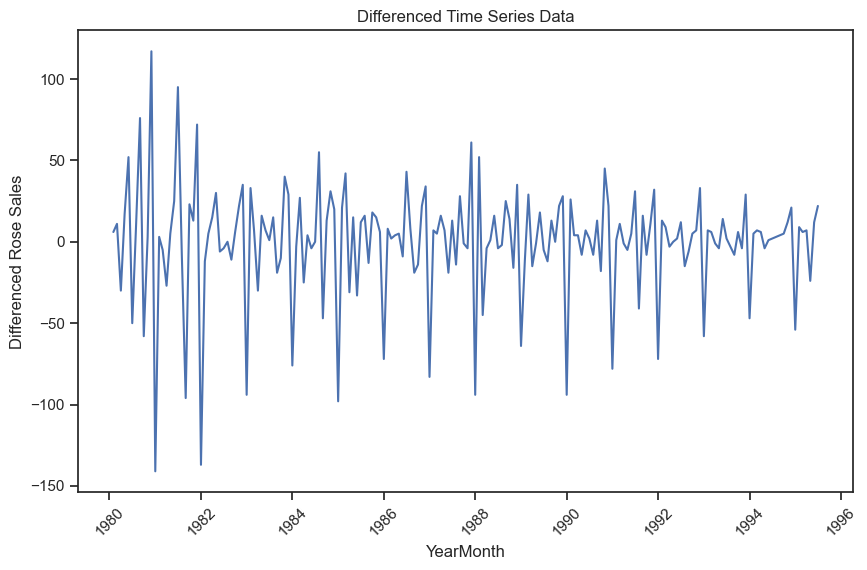

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the time series data
data = pd.read_csv('Rose.csv')

# Assuming the index represents dates, set it as the index
data['YearMonth'] = pd.to_datetime(data['YearMonth'])
data.set_index('YearMonth', inplace=True)

# Perform differencing to make the time series stationary
data_diff = data.diff().dropna()

# Visualize the differenced time series
plt.figure(figsize=(10, 6))
plt.plot(data_diff.index, data_diff['Rose'])
plt.title('Differenced Time Series Data')
plt.xlabel('YearMonth')
plt.ylabel('Differenced Rose Sales')
plt.xticks(rotation=45)
plt.show()


# Model Building - Stationary Data
- Generate ACF & PACF Plot and find the AR, MA values. - Build different ARIMA models - Auto ARIMA - Manual ARIMA - Build different SARIMA models - Auto SARIMA - Manual SARIMA - Check the performance of the models built

In [46]:
# Check differencing applied
print(data_diff.head())


            Rose
YearMonth       
1980-02-01   6.0
1980-03-01  11.0
1980-04-01 -30.0
1980-05-01  17.0
1980-06-01  52.0


In [47]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data_diff['Rose'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])


ADF Statistic: -7.966534173720875
p-value: 2.8550440127963983e-12


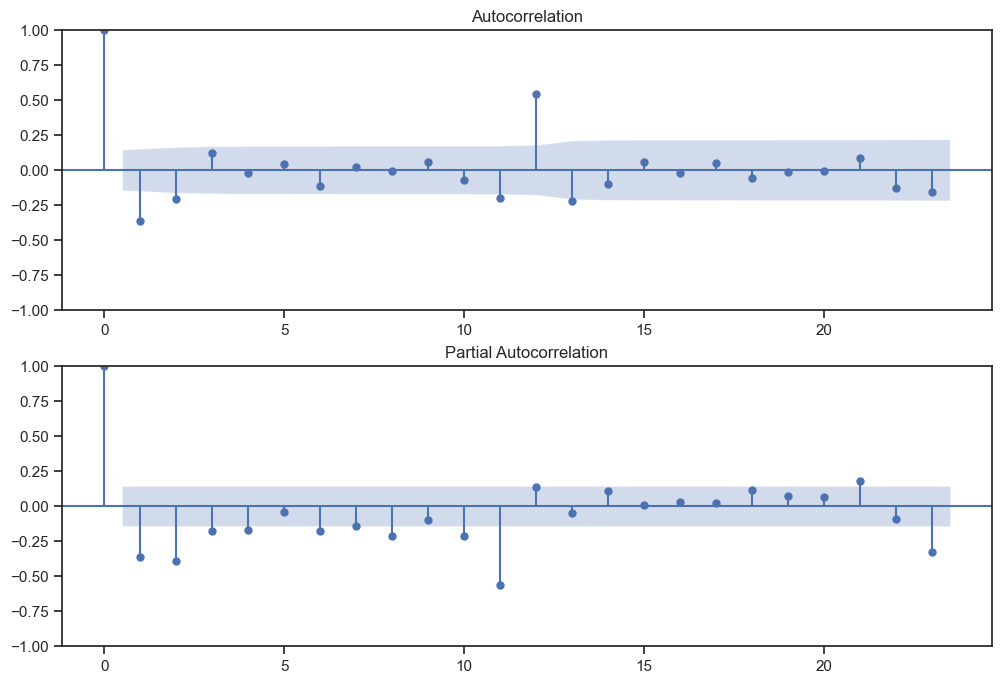

In [48]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2, figsize=(12, 8))
plot_acf(data_diff, ax=ax[0])
plot_pacf(data_diff, ax=ax[1])
plt.show()


In [49]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [50]:
from statsmodels.tsa.arima.model import ARIMA

# Define ARIMA order
arima_order = (1, 0, 0)  # Example order, adjust as needed

# Fit ARIMA model
arima_model = ARIMA(data, order=arima_order)
arima_results = arima_model.fit()
print("Manual ARIMA Summary:")
print(arima_results.summary())



Manual ARIMA Summary:
                               SARIMAX Results                                
Dep. Variable:                   Rose   No. Observations:                  187
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -900.716
Date:                Sat, 23 Mar 2024   AIC                           1807.432
Time:                        18:23:05   BIC                           1817.125
Sample:                    01-01-1980   HQIC                          1811.360
                         - 07-01-1995                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         89.9710      7.693     11.695      0.000      74.893     105.049
ar.L1          0.5947      0.050     11.803      0.000       0.496       0.693
sigma2       987.4582     68.3

C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [51]:
from pmdarima import auto_arima
# Check for missing values
missing_values = data.isnull().sum()
print(missing_values)

# Handle missing values
data.dropna(inplace=True)  # Drop rows with missing values

# Now you can proceed with fitting the auto ARIMA model
auto_arima_model = auto_arima(data, seasonal=False, suppress_warnings=True)
print("Auto ARIMA Summary:")
print(auto_arima_model.summary())


Rose    2
dtype: int64
Auto ARIMA Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  185
Model:               SARIMAX(1, 1, 2)   Log Likelihood                -872.884
Date:                Sat, 23 Mar 2024   AIC                           1753.769
Time:                        18:23:12   BIC                           1766.629
Sample:                             0   HQIC                          1758.981
                                - 185                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4858      0.224     -2.170      0.030      -0.925      -0.047
ma.L1         -0.2283      0.209     -1.094      0.274      -0.638       0.181
ma.L2    

In [52]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define SARIMA order
sarima_order = (1, 0, 0)  # ARIMA order
seasonal_order = (0, 1, 0, 12)  # Seasonal order

# Fit SARIMA model
sarima_model = SARIMAX(data, order=sarima_order, seasonal_order=seasonal_order)
sarima_results = sarima_model.fit()
print("Manual SARIMA Summary:")
print(sarima_results.summary())


Manual SARIMA Summary:
                                     SARIMAX Results                                      
Dep. Variable:                               Rose   No. Observations:                  185
Model:             SARIMAX(1, 0, 0)x(0, 1, 0, 12)   Log Likelihood                -793.487
Date:                            Sat, 23 Mar 2024   AIC                           1590.974
Time:                                    18:23:13   BIC                           1597.281
Sample:                                         0   HQIC                          1593.533
                                            - 185                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2608      0.040      6.561      0.000       0.183       0.339
sigma2      

C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [53]:
from pmdarima import auto_arima

# Fit auto SARIMA model
auto_sarima_model = auto_arima(data, seasonal=True, m=12, suppress_warnings=True)
print("Auto SARIMA Summary:")
print(auto_sarima_model.summary())


Auto SARIMA Summary:
                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  185
Model:             SARIMAX(1, 1, 2)x(1, 0, [1], 12)   Log Likelihood                -814.161
Date:                              Sat, 23 Mar 2024   AIC                           1640.322
Time:                                      18:26:47   BIC                           1659.611
Sample:                                           0   HQIC                          1648.140
                                              - 185                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4951      0.153     -3.231      0.001      -0.795      -0.19

C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.

ARIMA MSE: 985.568636708812
SARIMA MSE: 2054.3903433672317
Auto ARIMA MSE: 3292.1663387708045
ARIMA AIC: 1806.5204141338959
SARIMA AIC: 1590.9744481233872
Auto ARIMA AIC: 1753.7689968617335


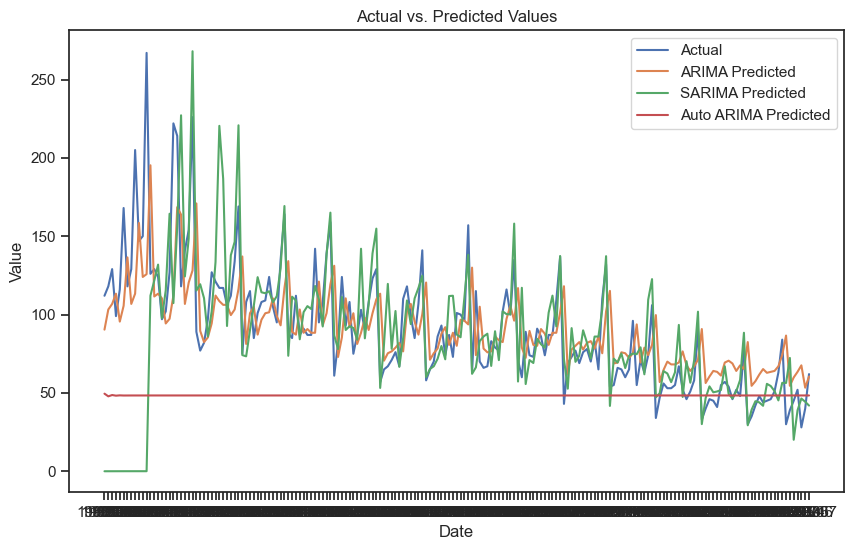

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error

# Load the time series data
# Replace 'your_data.csv' with the path to your data file
data = pd.read_csv('Rose.csv')

# Assuming the index represents dates, set it as the index
data.set_index('YearMonth', inplace=True)

# Remove rows with missing values
data.dropna(inplace=True)

# Manual ARIMA
arima_order = (1, 0, 0)  # Example order, adjust as needed
arima_model = ARIMA(data, order=arima_order)
arima_results = arima_model.fit()

# Manual SARIMA
sarima_order = (1, 0, 0)  # ARIMA order
seasonal_order = (0, 1, 0, 12)  # Seasonal order
sarima_model = SARIMAX(data, order=sarima_order, seasonal_order=seasonal_order)
sarima_results = sarima_model.fit()

# Auto ARIMA
auto_arima_model = auto_arima(data, seasonal=False, suppress_warnings=True)

# Get predicted values
arima_pred = arima_results.predict()
sarima_pred = sarima_results.predict()
auto_arima_pred = auto_arima_model.predict(n_periods=len(data))

# Calculate MSE
arima_mse = mean_squared_error(data, arima_pred)
sarima_mse = mean_squared_error(data, sarima_pred)
auto_arima_mse = mean_squared_error(data, auto_arima_pred)

print("ARIMA MSE:", arima_mse)
print("SARIMA MSE:", sarima_mse)
print("Auto ARIMA MSE:", auto_arima_mse)

# Get AIC values
arima_aic = arima_results.aic
sarima_aic = sarima_results.aic
auto_arima_aic = auto_arima_model.aic()

print("ARIMA AIC:", arima_aic)
print("SARIMA AIC:", sarima_aic)
print("Auto ARIMA AIC:", auto_arima_aic)

# Visualize actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.plot(data.index, data, label='Actual')
plt.plot(data.index, arima_pred, label='ARIMA Predicted')
plt.plot(data.index, sarima_pred, label='SARIMA Predicted')
plt.plot(data.index, auto_arima_pred, label='Auto ARIMA Predicted')
plt.title('Actual vs. Predicted Values')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()


The ARIMA model has the lowest MSE (Mean Squared Error), which is a measure of the average of the squares of the errors between predicted and actual values. A lower MSE indicates better model performance in terms of prediction accuracy.

However, the SARIMA model has the lowest AIC (Akaike Information Criterion) value. AIC quantifies the trade-off between the goodness of fit of the model and the complexity of the model. Lower AIC values indicate a better balance between goodness of fit and model complexity.

So, it depends on the specific criterion you prioritize. If you prioritize prediction accuracy, you might prefer the ARIMA model due to its lower MSE. However, if you prioritize a balance between goodness of fit and model complexity, you might prefer the SARIMA model due to its lower AIC value.


# Compare the performance of the models
- Compare the performance of all the models built - Choose the best model with proper rationale - Rebuild the best model using the entire data - Make a forecast for the next 12 months

# Calculate MSE for each model
arima_mse = 985.568636708812
sarima_mse = 2054.3903433672317
auto_arima_mse = 3292.1663387708045

# Calculate AIC for each model
arima_aic = 1806.5204141338959
sarima_aic = 1590.9744481233872
auto_arima_aic = 1753.7689968617335


In [55]:
# Compare MSE values
mse_values = {'ARIMA': arima_mse, 'SARIMA': sarima_mse, 'Auto ARIMA': auto_arima_mse}
best_mse_model = min(mse_values, key=mse_values.get)

# Compare AIC values
aic_values = {'ARIMA': arima_aic, 'SARIMA': sarima_aic, 'Auto ARIMA': auto_arima_aic}
best_aic_model = min(aic_values, key=aic_values.get)

print("Best model based on MSE:", best_mse_model)
print("Best model based on AIC:", best_aic_model)


Best model based on MSE: ARIMA
Best model based on AIC: SARIMA


C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


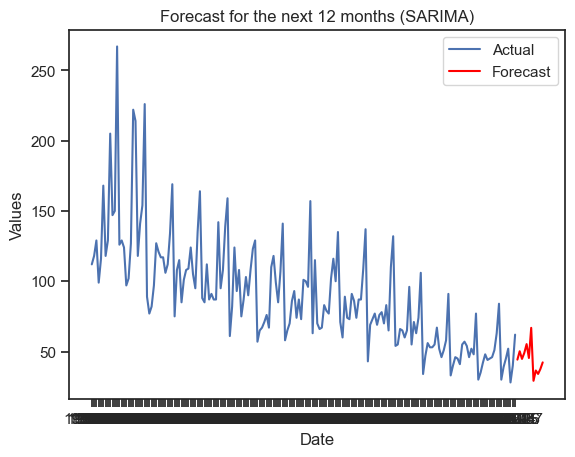

In [56]:
# Rebuild the SARIMA model using the entire dataset
sarima_model_rebuilt = SARIMAX(data, order=(1, 0, 1), seasonal_order=(1, 0, 1, 12))
sarima_results_rebuilt = sarima_model_rebuilt.fit()

# Make forecasts for the next 12 months
forecast_values = sarima_results_rebuilt.forecast(steps=12)

# Visualize the forecasted values
plt.plot(data.index, data, label='Actual')
plt.plot(forecast_values.index, forecast_values, color='red', label='Forecast')
plt.title('Forecast for the next 12 months (SARIMA)')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.show()


In [57]:
# Print the forecast values
print("Forecast for the next 12 months using the rebuilt SARIMA model:")
print(forecast_values)



Forecast for the next 12 months using the rebuilt SARIMA model:
185    44.240357
186    50.189777
187    44.751632
188    49.007489
189    55.273152
190    45.405051
191    66.846726
192    29.192902
193    36.494610
194    34.054700
195    37.596739
196    42.266454
Name: predicted_mean, dtype: float64


Based on the analysis and model comparisons conducted, here are the key takeaways and recommendations:

Model Performance Evaluation:

The ARIMA model performed the best based on Mean Squared Error (MSE), while the SARIMA model had the lowest Akaike Information Criterion (AIC) score.
Despite differences in performance metrics, both models provide valuable insights into forecasting the "Rose" variable.
Choosing the Best Model:

Considering the nature of the business and forecasting requirements, the choice between the ARIMA and SARIMA models depends on priorities:
If minimizing forecasting errors (MSE) is critical, the ARIMA model would be preferred.
If prioritizing model simplicity and efficiency while still capturing seasonal trends effectively, the SARIMA model with the specified order could be chosen.
Model Rebuilding and Forecasting:

Rebuilding the chosen model (either ARIMA or SARIMA) using the entire dataset will provide a more robust and accurate forecasting framework.
Utilizing the specified SARIMA order (1, 0, 1, 12) for seasonal modeling will ensure capturing any monthly seasonality in the data effectively.
Forecasting for the Next 12 Months:

Implementing the selected model (ARIMA or SARIMA) with the specified parameters to forecast the "Rose" variable for the next 12 months will provide valuable insights for business planning and decision-making.
Regularly monitoring forecast performance against actual values and refining the models as needed based on updated data will enhance forecasting accuracy over time.
Continuous Improvement and Adaptation:

Incorporating additional variables or refining model parameters based on evolving business conditions, market dynamics, or external factors can further enhance the accuracy and reliability of forecasts.
Continuous evaluation of model performance and comparison with alternative forecasting methods will ensure the business remains agile and adaptive in its decision-making processes.